## Project Proposal: Predicting Hotel Cancellations to Optimize Revenue 
Hotel cancellations represent one of the most significant sources of revenue loss in the hospitality industry. From 2014-2018, the global average hotel cancellation rate was around 40% D-Edge Hospitality Solutions (2019). 

Our research question is: Given the features available at the time of booking, how accurately can we predict whether a reservation will be canceled, and which booking characteristics drive cancellation risk most strongly?

## Import Libraries

In [8]:
! pip install tensorflow keras_tuner

  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [keras_tuner]


In [9]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist
import keras_tuner as kt
from keras_tuner import HyperParameters
tf.get_logger().setLevel('INFO')
print("Done Importing")

Done Importing


## Load Data

In [10]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Processing

In [11]:
#Learn about data
print(f"Data shape: {df.shape}")
print("The column names are:", df.columns)
print("The unique value count for each column is:",df.nunique())
print("N/A's for each column:", df.isna().sum())

Data shape: (119390, 32)
The column names are: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')
The unique value count for each column is: hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12


In [12]:
#Handling Missing Values
#Fill missing values
df["children"]= df["children"].fillna(0).astype(int)
df["country"]= df["country"].fillna("N/A")

#Validation on >1 guest 
total_guests= df["adults"] + df["children"] + df["babies"]
df= df[total_guests > 0].copy()

# #Add total nights column
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

#reserved and assigned room type mismatch res status + res statis date
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Drop cols
df = df.drop(columns=["agent", "reserved_room_type", "assigned_room_type", "company", "meal", "market_segment", "reservation_status", "reservation_status_date"])

# Total party size
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
print(f"Data shape: {df.shape}")

Data shape: (119210, 27)


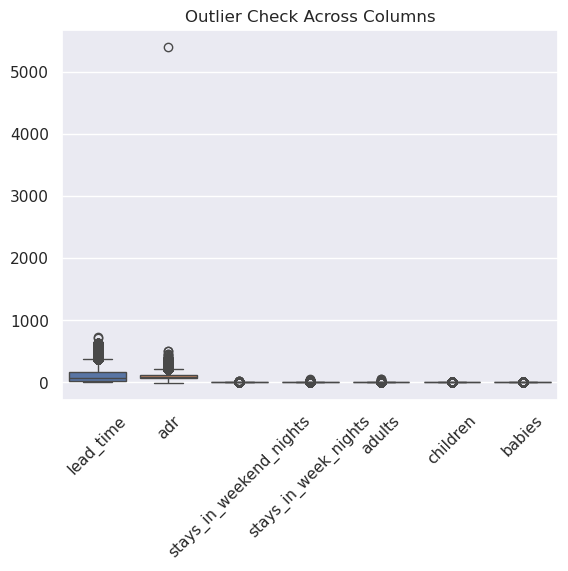

In [13]:
#Outlier Detection
numerical_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies",]
sns.boxplot(df[numerical_cols])
plt.title("Outlier Check Across Columns")
plt.xticks(rotation=45)
plt.show()
#one outlier exists in adr
df = df[(df["adr"] < 5000)]
plt.show()

In [14]:
# Log Normalization
df["lead_time_log"] = np.log1p(df["lead_time"])
df["adr_log"] =np.log1p(df["adr"])

/srv/conda/envs/notebook/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
# Encoding
#map this
df["hotel"] = df["hotel"].map({"City Hotel": 1, "Resort Hotel": 0})
#frequency encode country cause too many variables
country_frequencies = df["country"].value_counts(normalize=True)
df["country_encoded"] = df["country"].map(country_frequencies)
df = df.drop(columns=["country"])
#one hot encode targets
one_hot_targets = ["deposit_type", "customer_type", "distribution_channel", "arrival_date_month"]
df = pd.get_dummies(df, columns=one_hot_targets, drop_first=True, dtype=int)
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
0,0,0,342,2015,27,1,0,0,2,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,737,2015,27,1,0,0,2,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,7,2015,27,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,13,2015,27,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,14,2015,27,1,0,2,2,0,...,0,0,0,1,0,0,0,0,0,0


## Data Split

Split dataset into train and test with 8:2 ratio

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [23]:
df.to_csv("../data/processed/processed_data.csv", index=False)
train_df.to_csv("../data/processed/processed_data_train.csv", index=False)
test_df.to_csv("../data/processed/processed_data_test.csv", index=False)